In [ ]:
# PART A: Understanding the Dataset
# Q1.Dataset Overview
# No. of rows and columns
import pandas as pd
df = pd.read_csv("agriculture_ml_dataset_cw.csv")
print(df.shape)
# Names of columns
print(df.columns)
# First 10 columns
print(df.head(10))

# Q2.Data Types and Missing Values
# Data Type of each column
print(df.dtypes)
# Identify whether any missing values are present
print(df.isnull().sum())
# If missing values exist, mention the affected columns
missing = df.isnull().sum()
print(missing[missing > 0])

# Q3.Descriptive Statistics
# Which feature has the highest mean value?
print(df.mean(numeric_only=True))
# Which feature has the highest standard deviation?
print(df.std(numeric_only=True))

(2020, 11)
Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen',
       'Yield'],
      dtype='object')
   Crop_Type Soil_Type Region  Season Irrigation Fertilizer  Rainfall  \
0      Wheat     Silty  South  Kharif  Sprinkler   Chemical      93.7   
1     Cotton       NaN   West    Zaid      Flood    Organic     146.9   
2     Cotton      Clay  North  Kharif       Drip   Chemical     108.7   
3      Maize      Clay  South  Kharif  Sprinkler   Chemical      72.3   
4      Maize     Silty   West  Kharif      Flood    Organic     119.9   
5  Sugarcane     Loamy   West    Rabi      Flood      Mixed     176.4   
6      Wheat      Clay  South    Rabi  Sprinkler   Chemical     146.1   
7     Cotton     Loamy   East    Zaid        NaN    Organic     200.6   
8       Rice     Silty  North    Rabi       Drip      Mixed     136.2   
9      Wheat     Sandy  North    Rabi  Sprinkler    Organic     215.7   

   Temp

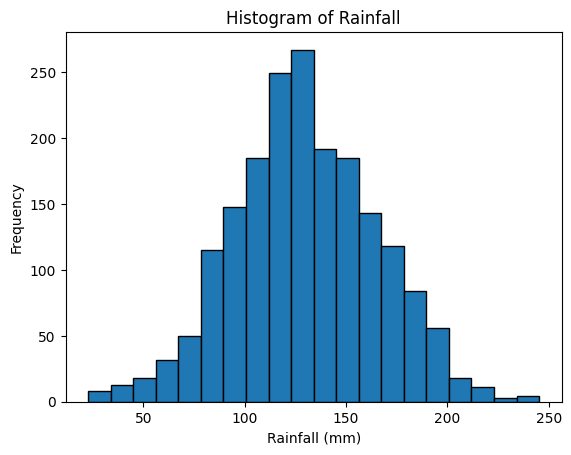

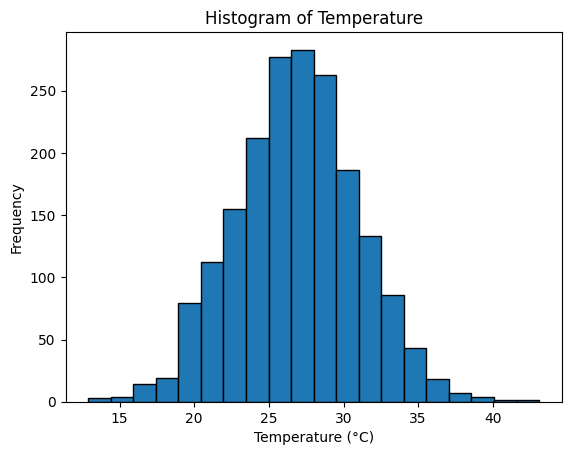

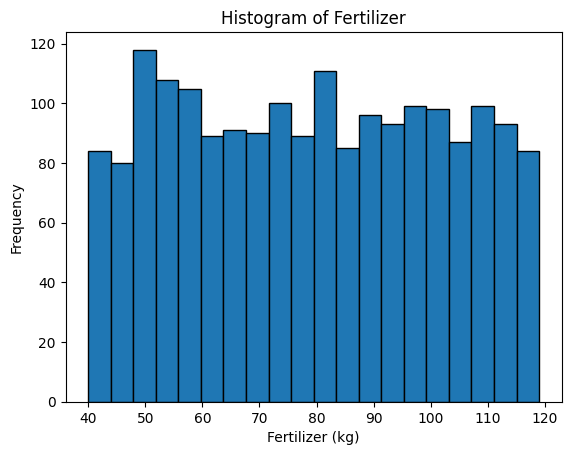

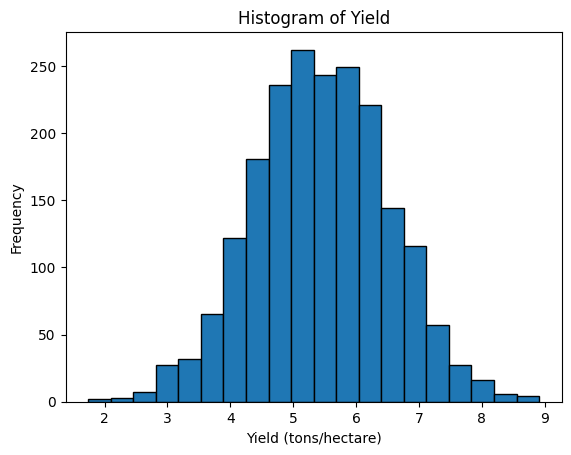

Crop_Type
Maize        426
Wheat        422
Sugarcane    403
Cotton       399
Rice         370
Name: count, dtype: int64


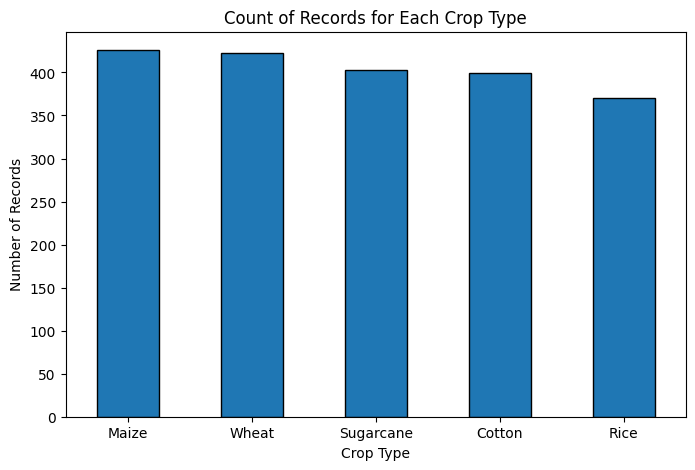

Soil_Type
Silty    493
Loamy    482
Clay     463
Sandy    461
Name: count, dtype: int64


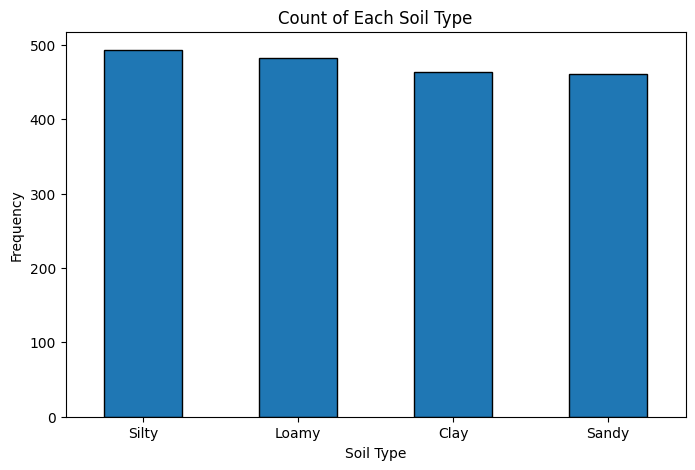

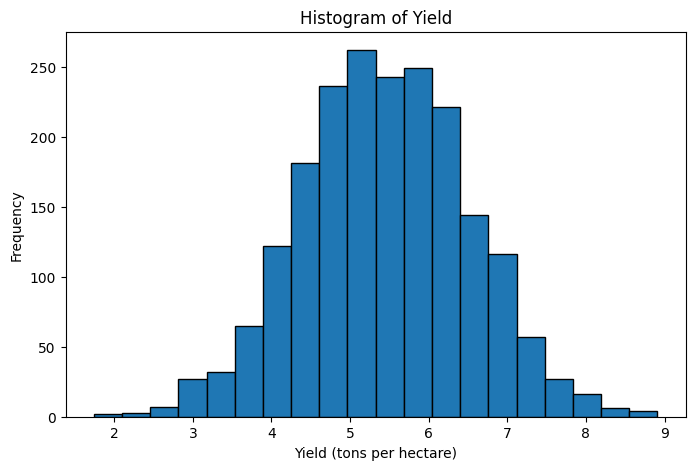

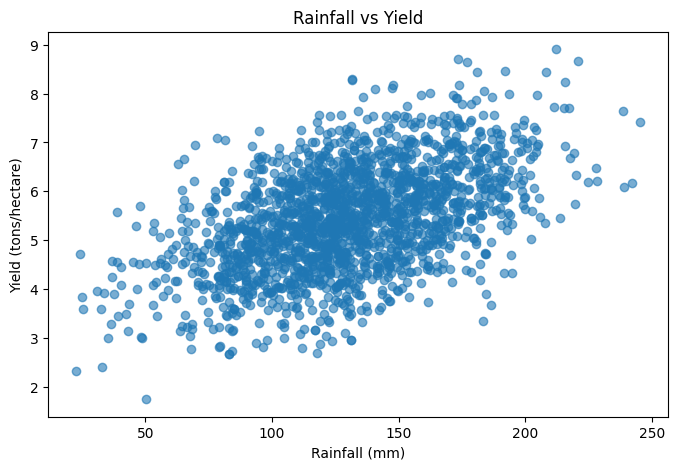

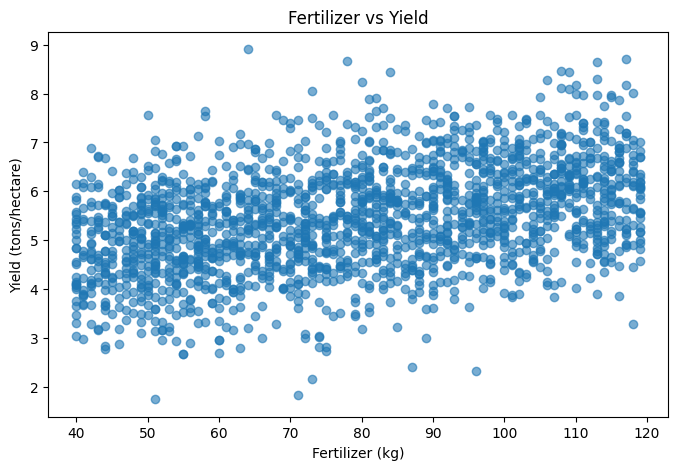

             Rainfall  Temperature  Humidity  Nitrogen     Yield
Rainfall     1.000000    -0.013519  0.002204 -0.031158  0.498788
Temperature -0.013519     1.000000  0.007016  0.029948  0.023503
Humidity     0.002204     0.007016  1.000000  0.017116  0.013557
Nitrogen    -0.031158     0.029948  0.017116  1.000000  0.395801
Yield        0.498788     0.023503  0.013557  0.395801  1.000000


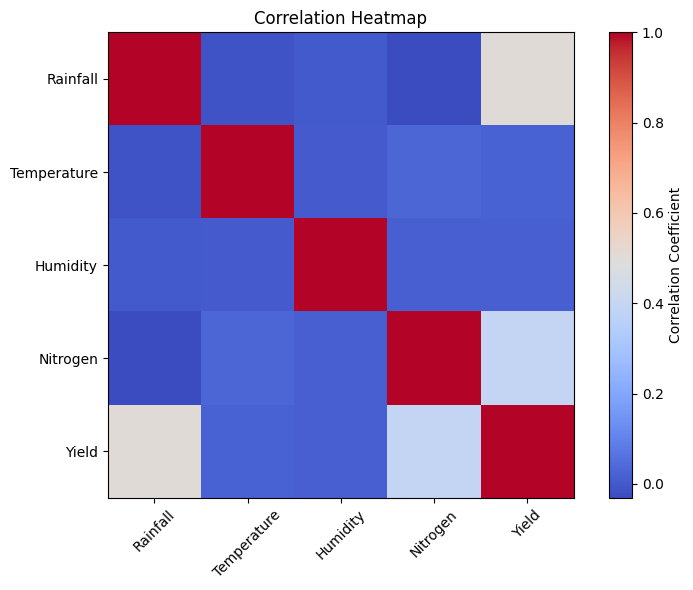

Yield          1.000000
Rainfall       0.498788
Nitrogen       0.395801
Temperature    0.023503
Humidity       0.013557
Name: Yield, dtype: float64
Average Yield by Crop Type:
Crop_Type
Cotton       5.434286
Maize        5.439014
Rice         5.368919
Sugarcane    5.445434
Wheat        5.517536
Name: Yield, dtype: float64

Average Yield by Soil Type:
Soil_Type
Clay     5.509352
Loamy    5.347427
Sandy    5.452777
Silty    5.439919
Name: Yield, dtype: float64


In [ ]:
# PART B: Exploratory Data Analysis (EDA)
# Q4.Distribution Analysis
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("agriculture_ml_dataset_cw.csv")

# Histogram for rainfall_mm
plt.hist(df["Rainfall"].dropna(), bins=20, edgecolor="black")
plt.title("Histogram of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()
# Histogram for temperature_c
plt.hist(df["Temperature"].dropna(), bins=20, edgecolor="black")
plt.title("Histogram of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()
# Histogram for fertilizer_kg
plt.hist(df["Nitrogen"].dropna(), bins=20, edgecolor="black")
plt.title("Histogram of Fertilizer")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")
plt.show()
# Histogram for yield_ton_per_hectare
plt.hist(df["Yield"].dropna(), bins=20, edgecolor="black")
plt.title("Histogram of Yield")
plt.xlabel("Yield (tons/hectare)")
plt.ylabel("Frequency")
plt.show()

# Q5.Crop Type Analysis
# Count records for each crop type
crop_counts = df["Crop_Type"].value_counts()
print(crop_counts)
# Create a bar chart
plt.figure(figsize=(8, 5))
crop_counts.plot(kind="bar", edgecolor="black")
plt.title("Count of Records for Each Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()
# Maize apppears most frequently in dataset

# Q6.Soil Type Analysis
# Count the frequency of each soil type
soil_counts = df["Soil_Type"].value_counts()
# Display the result
print(soil_counts)
# Create the count plot
df["Soil_Type"].value_counts().plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Count of Each Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()
# Loamy soil is the most common soil type in the dataset

# Q7.Yield Distribution
# Create histogram for Yield
plt.figure(figsize=(8, 5))
plt.hist(df["Yield"].dropna(), bins=20, edgecolor="black")

plt.title("Histogram of Yield")
plt.xlabel("Yield (tons per hectare)")
plt.ylabel("Frequency")
plt.show()
# The distribution of yield appears to be approximetly normal(bell shaped)
# No major outliers are noticable

# Q8.Scatter Plot Analysis
# Scatter plot: Rainfall vs Yield
plt.figure(figsize=(8, 5))
plt.scatter(df["Rainfall"], df["Yield"], alpha=0.6)

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tons/hectare)")

plt.show()
# Scatter plot: Fertilizer (kg) vs Yield
plt.figure(figsize=(8, 5))
plt.scatter(df["Nitrogen"], df["Yield"], alpha=0.6)

plt.title("Fertilizer vs Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield (tons/hectare)")

plt.show()
# Nitrogen appears to have stronger relationship with yield

# Q9.Correlation Analysis
# Select only numerical columns
numerical_df = df.select_dtypes(include=["number"])

# Generate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
print(correlation_matrix)
# Compute correlation matrix
correlation_matrix = df.select_dtypes(include=["number"]).corr()

# Create heatmap
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

# Add labels
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=45)
plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

# Add color bar
plt.colorbar(label="Correlation Coefficient")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
# Correlation of all numerical features with Yield
yield_corr = correlation_matrix["Yield"].sort_values(ascending=False)
print(yield_corr)

# Q10.Group-Based Analysis
# Average yield for each crop type
avg_crop_yield = df.groupby("Crop_Type")["Yield"].mean()
print("Average Yield by Crop Type:")
print(avg_crop_yield)

# Average yield for each soil type
avg_soil_yield = df.groupby("Soil_Type")["Yield"].mean()
print("\nAverage Yield by Soil Type:")
print(avg_soil_yield)
# Crop type with the highest average yield: Wheat
# Soil type with the highest average yield: Clay

In [ ]:
# PART C: Data Preparation
# Q11.Feature Encoding
# Display categorical columns
print(df.select_dtypes(include="object").columns)
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=[
    "Crop_Type",
    "Soil_Type",
    "Region",
    "Season",
    "Irrigation",
    "Fertilizer"
])

# Display the first 5 rows
print(df_encoded.head())
# Note: If you want the encoded columns to contain 0 and 1 as integers instead of True and False, use:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Crop_Type",
        "Soil_Type",
        "Region",
        "Season",
        "Irrigation",
        "Fertilizer"
    ],
    dtype=int
)
# # Display first five rows
print(df_encoded.head())

# Q12.Feature Selection
# Input features (X)
X = df.drop("Yield", axis=1)

# Target variable (y)
y = df["Yield"]

# Display X and y
print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())
# Yield column is used as target variable

Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer'],
      dtype='object')
   Rainfall  Temperature  Humidity  Nitrogen  Yield  Crop_Type_Cotton  \
0      93.7         22.9      69.0     115.0   5.13             False   
1     146.9         25.6       NaN      71.0   5.40              True   
2     108.7         22.1       NaN      86.0   4.26              True   
3      72.3         26.8      69.4      44.0   4.35             False   
4     119.9         26.3      44.3      48.0   4.88             False   

   Crop_Type_Maize  Crop_Type_Rice  Crop_Type_Sugarcane  Crop_Type_Wheat  ...  \
0            False           False                False             True  ...   
1            False           False                False            False  ...   
2            False           False                False            False  ...   
3             True           False                False            False  ...   
4             True           False           

In [ ]:
# PART D: Machine Learning
# Q13.Train-Test Split
from sklearn.model_selection import train_test_split

# Separate input features (X) and target variable (y)
X = df.drop("Yield", axis=1)
y = df["Yield"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Q14.Linear Regression Model
from sklearn.linear_model import LinearRegression

# Fill missing values
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].mean())

# One-Hot Encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_encoded.drop("Yield", axis=1)
y = df_encoded["Yield"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Display coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print("\nCoefficients:")
print(coefficients)

# Feature with the highest positive coefficient
highest = coefficients.loc[coefficients["Coefficient"].idxmax()]
print("\nHighest Positive Coefficient:")
print(highest)

# How to display intercept
print(model.intercept_)

# How to display the coefficients
print(model.coef_)
# (or)
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})
print(coefficients)

# Which feature has the highest positive coefficient?
highest = coefficients.loc[coefficients["Coefficient"].idxmax()]
print(highest)

X_train shape: (1616, 10)
X_test shape: (404, 10)
y_train shape: (1616,)
y_test shape: (404,)
Intercept: 1.755899512491503

Coefficients:
                 Feature  Coefficient
0               Rainfall     0.015030
1            Temperature     0.006897
2               Humidity     0.000433
3               Nitrogen     0.019346
4        Crop_Type_Maize     0.090065
5         Crop_Type_Rice    -0.010919
6    Crop_Type_Sugarcane     0.071520
7        Crop_Type_Wheat     0.115868
8        Soil_Type_Loamy    -0.115456
9        Soil_Type_Sandy    -0.069547
10       Soil_Type_Silty    -0.088306
11          Region_North     0.057605
12          Region_South     0.043416
13           Region_West     0.004842
14           Season_Rabi     0.022239
15           Season_Zaid    -0.028681
16      Irrigation_Flood    -0.053431
17  Irrigation_Sprinkler    -0.066225
18      Fertilizer_Mixed     0.058548
19    Fertilizer_Organic     0.004208

Highest Positive Coefficient:
Feature        Crop_Type_Wheat
Co